In [1]:
!git clone https://github.com/Aishwarya-cell188/PixelPhoenix-KLA-PS01.git


Cloning into 'PixelPhoenix-KLA-PS01'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [2]:
%cd PixelPhoenix-KLA-PS01

/content/PixelPhoenix-KLA-PS01


In [3]:
!pip install torch torchvision scikit-image lpips -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.2 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!unzip -q "/content/drive/MyDrive/train.zip" -d /content/data

In [6]:
!find /content/drive/MyDrive -iname "*train*"

/content/drive/MyDrive/Colab Notebooks/KLA_training.ipynb
/content/drive/MyDrive/Colab Notebooks/KLA_training2.ipynb
/content/drive/MyDrive/train.zip


In [7]:
!unzip -q "/content/drive/MyDrive/train.zip" -d /content/data

replace /content/data/__MACOSX/._train? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [8]:
!ls -la "/content/drive/MyDrive/"

total 972392
-rw------- 1 root root   6813891 Sep  7  2025  20250907_170337.PDF
-rw------- 1 root root   8925537 Mar 20 08:24 'Article 1'
-rw------- 1 root root   1873621 Aug 13 15:04  best_model_checkpoint.pth
drwx------ 2 root root      4096 Mar 29 07:13 'Colab Notebooks'
-rw------- 1 root root       183 Mar  5 12:24 'Copy of Copy of POC Structure_Participants.gdoc'
-rw------- 1 root root       183 Mar  5 12:22 'Copy of POC Structure_Participants.gdoc'
-rw------- 1 root root    313710 Oct 26  2025  DOC-20251025-WA0011..pdf
-rw------- 1 root root   1186695 May  6 11:40  DOC-20260506-WA0016.docx
-rw------- 1 root root     41780 Apr 12 06:18 'KT on Fullstack.docx'
-rw------- 1 root root       183 May 27 08:26 'MOVIE STORY  PART 1.rtf.gdoc'
-rw------- 1 root root     19235 Sep  7  2025  PHOTO.JPG
-rw------- 1 root root       183 Mar  5 11:56 'POC Structure_Participants (1).gdoc'
-rw------- 1 root root       183 Mar  5 09:42 'POC Structure_Participants (2).gdoc'
-rw------- 1 root root    

In [9]:
!ls -la "/content/drive/MyDrive/" | grep -i -E "train|test"

-r-------- 1 root root  23419125 Jul 28 06:13 Test_NoisyLR.zip
-r-------- 1 root root 918994209 Jul 28 06:13 train.zip


In [10]:
!unzip -q "/content/drive/MyDrive/train.zip" -d /content/data

replace /content/data/__MACOSX/._train? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
!ls /content/data

__MACOSX  train


In [12]:
!ls /content/data/train

GT  NoisyLR


In [13]:
!ls /content/data/train/GT | head -5
!ls /content/data/train/NoisyLR | head -5

000000.npy
000001.npy
000002.npy
000003.npy
000004.npy
000000.npy
000001.npy
000002.npy
000003.npy
000004.npy


In [14]:
import numpy as np

gt = np.load('/content/data/train/GT/000000.npy')
noisy = np.load('/content/data/train/NoisyLR/000000.npy')

print("GT shape:", gt.shape, "dtype:", gt.dtype, "min:", gt.min(), "max:", gt.max())
print("NoisyLR shape:", noisy.shape, "dtype:", noisy.dtype, "min:", noisy.min(), "max:", noisy.max())

GT shape: (256, 256) dtype: float32 min: 0.0 max: 1.0
NoisyLR shape: (128, 128) dtype: float32 min: -0.0026427102 max: 1.3257757


In [15]:
import os

files = sorted(os.listdir('/content/data/train/GT'))
print("Total pairs:", len(files))

# check a few different files for shape variety
for f in files[:3] + files[len(files)//2:len(files)//2+2] + files[-3:]:
    gt = np.load(f'/content/data/train/GT/{f}')
    noisy = np.load(f'/content/data/train/NoisyLR/{f}')
    print(f, "GT:", gt.shape, "Noisy:", noisy.shape)

Total pairs: 3200
000000.npy GT: (256, 256) Noisy: (128, 128)
000001.npy GT: (256, 256) Noisy: (128, 128)
000002.npy GT: (256, 256) Noisy: (128, 128)
001600.npy GT: (256, 256) Noisy: (128, 128)
001601.npy GT: (256, 256) Noisy: (128, 128)
003197.npy GT: (256, 256) Noisy: (128, 128)
003198.npy GT: (256, 256) Noisy: (128, 128)
003199.npy GT: (256, 256) Noisy: (128, 128)


In [16]:
import torch
from torch.utils.data import Dataset
import numpy as np

class RestorationDataset(Dataset):
    def __init__(self, gt_dir, noisy_dir):
        self.gt_dir = gt_dir
        self.noisy_dir = noisy_dir
        self.files = sorted(os.listdir(gt_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        gt = np.load(f"{self.gt_dir}/{fname}")        # (256, 256)
        noisy = np.load(f"{self.noisy_dir}/{fname}")  # (128, 128)

        gt = torch.from_numpy(gt).unsqueeze(0).float()        # -> (1, 256, 256)
        noisy = torch.from_numpy(noisy).unsqueeze(0).float()  # -> (1, 128, 128)

        # upsample noisy to match GT size so the model has a fixed-size input to refine
        noisy = torch.nn.functional.interpolate(
            noisy.unsqueeze(0), size=gt.shape[-2:], mode='bicubic', align_corners=False
        ).squeeze(0)

        # clamp the out-of-range noise values back to valid [0,1] before feeding the model
        noisy = torch.clamp(noisy, 0.0, 1.0)

        return noisy, gt

In [17]:
dataset = RestorationDataset('/content/data/train/GT', '/content/data/train/NoisyLR')
x, y = dataset[0]
print("Input shape:", x.shape, "Target shape:", y.shape)
print("Input range:", x.min().item(), x.max().item())

Input shape: torch.Size([1, 256, 256]) Target shape: torch.Size([1, 256, 256])
Input range: 0.0 1.0


In [18]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.9 * len(dataset))   # 90% train
val_size = len(dataset) - train_size   # 10% validation

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print("Train pairs:", len(train_dataset), "Val pairs:", len(val_dataset))

Train pairs: 2880 Val pairs: 320


In [19]:
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
                                   nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
                                   nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
                                         nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
                                   nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
                                   nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))

In [20]:
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def l1_loss(pred, target):
    return torch.mean(torch.abs(pred - target))

In [21]:
import copy

def train_model(model, train_loader, val_loader, optimizer, device, epochs=10):
    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for noisy, gt in train_loader:
            noisy, gt = noisy.to(device), gt.to(device)
            optimizer.zero_grad()
            pred = model(noisy)
            loss = l1_loss(pred, gt)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for noisy, gt in val_loader:
                noisy, gt = noisy.to(device), gt.to(device)
                pred = model(noisy)
                loss = l1_loss(pred, gt)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"  → New best model saved (val loss: {val_loss:.4f})")

    model.load_state_dict(best_model_weights)
    return model

In [22]:
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=10)

Epoch 1/10 — Train Loss: 0.0560, Val Loss: 0.0396
  → New best model saved (val loss: 0.0396)
Epoch 2/10 — Train Loss: 0.0402, Val Loss: 0.0375
  → New best model saved (val loss: 0.0375)
Epoch 3/10 — Train Loss: 0.0393, Val Loss: 0.0372
  → New best model saved (val loss: 0.0372)
Epoch 4/10 — Train Loss: 0.0379, Val Loss: 0.0395
Epoch 5/10 — Train Loss: 0.0371, Val Loss: 0.0359
  → New best model saved (val loss: 0.0359)
Epoch 6/10 — Train Loss: 0.0373, Val Loss: 0.0352
  → New best model saved (val loss: 0.0352)
Epoch 7/10 — Train Loss: 0.0364, Val Loss: 0.0356
Epoch 8/10 — Train Loss: 0.0362, Val Loss: 0.0342
  → New best model saved (val loss: 0.0342)
Epoch 9/10 — Train Loss: 0.0350, Val Loss: 0.0343
Epoch 10/10 — Train Loss: 0.0347, Val Loss: 0.0332
  → New best model saved (val loss: 0.0332)


In [25]:
!pip install pytorch-msssim -q
from pytorch_msssim import ssim

def combined_loss(pred, target, alpha=0.7):
    l1 = torch.mean(torch.abs(pred - target))
    s = 1 - ssim(pred, target, data_range=1.0, size_average=True)
    return alpha * l1 + (1 - alpha) * s

In [26]:
import torch

# Tiny overfit sanity check on 8 images
tiny_dataset = torch.utils.data.Subset(dataset, range(8))
tiny_loader = torch.utils.data.DataLoader(tiny_dataset, batch_size=8, shuffle=True)

model_test = UNet().to(device)
opt_test = optim.Adam(model_test.parameters(), lr=1e-3)

for epoch in range(200):
    model_test.train()
    noisy, gt = next(iter(tiny_loader))
    noisy, gt = noisy.to(device), gt.to(device)
    opt_test.zero_grad()
    pred = model_test(noisy)
    loss = combined_loss(pred, gt)
    loss.backward()
    opt_test.step()
    if epoch % 40 == 0:
        print(f"epoch {epoch} loss {loss.item():.4f}")

epoch 0 loss 0.3584
epoch 40 loss 0.1115
epoch 80 loss 0.1028
epoch 120 loss 0.0988
epoch 160 loss 0.0962


In [27]:
for epoch in range(200, 400):
    model_test.train()
    noisy, gt = next(iter(tiny_loader))
    noisy, gt = noisy.to(device), gt.to(device)
    opt_test.zero_grad()
    pred = model_test(noisy)
    loss = combined_loss(pred, gt)
    loss.backward()
    opt_test.step()
    if epoch % 40 == 0:
        print(f"epoch {epoch} loss {loss.item():.4f}")

epoch 200 loss 0.0942
epoch 240 loss 0.0929
epoch 280 loss 0.0908
epoch 320 loss 0.0876
epoch 360 loss 0.0887


In [28]:
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=10)

Epoch 1/10 — Train Loss: 0.0342, Val Loss: 0.0330
  → New best model saved (val loss: 0.0330)
Epoch 2/10 — Train Loss: 0.0340, Val Loss: 0.0327
  → New best model saved (val loss: 0.0327)
Epoch 3/10 — Train Loss: 0.0335, Val Loss: 0.0324
  → New best model saved (val loss: 0.0324)
Epoch 4/10 — Train Loss: 0.0337, Val Loss: 0.0326
Epoch 5/10 — Train Loss: 0.0334, Val Loss: 0.0322
  → New best model saved (val loss: 0.0322)
Epoch 6/10 — Train Loss: 0.0332, Val Loss: 0.0320
  → New best model saved (val loss: 0.0320)
Epoch 7/10 — Train Loss: 0.0331, Val Loss: 0.0325
Epoch 8/10 — Train Loss: 0.0330, Val Loss: 0.0328
Epoch 9/10 — Train Loss: 0.0332, Val Loss: 0.0318
  → New best model saved (val loss: 0.0318)
Epoch 10/10 — Train Loss: 0.0328, Val Loss: 0.0319


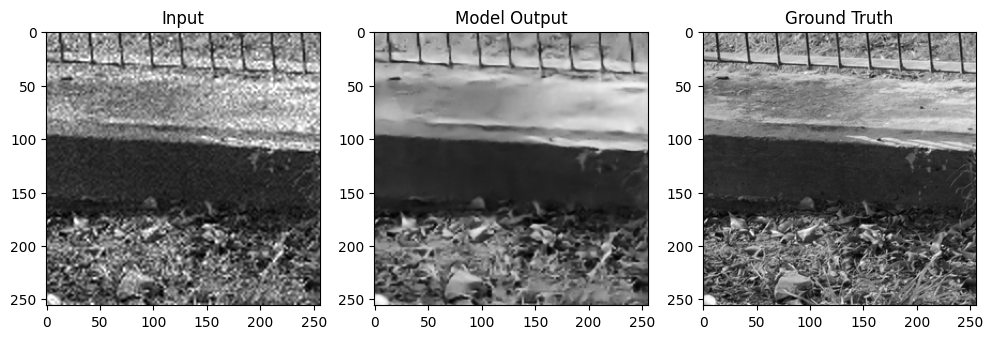

In [29]:
import matplotlib.pyplot as plt

model.eval()
noisy, gt = next(iter(val_loader))
noisy, gt = noisy.to(device), gt.to(device)
with torch.no_grad():
    pred = model(noisy)

idx = 0
fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(noisy[idx,0].cpu(), cmap='gray'); ax[0].set_title('Input')
ax[1].imshow(pred[idx,0].cpu(), cmap='gray'); ax[1].set_title('Model Output')
ax[2].imshow(gt[idx,0].cpu(), cmap='gray'); ax[2].set_title('Ground Truth')
plt.show()

In [30]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [31]:
def combined_loss(pred, target, alpha=0.7):
    l1 = torch.mean(torch.abs(pred - target))
    s = 1 - ssim(pred, target, data_range=1.0, size_average=True)
    return alpha * l1 + (1 - alpha) * s

In [32]:
def train_model(model, train_loader, val_loader, optimizer, device, epochs=25):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for noisy, gt in train_loader:
            noisy, gt = noisy.to(device), gt.to(device)
            optimizer.zero_grad()
            pred = model(noisy)
            loss = combined_loss(pred, gt)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for noisy, gt in val_loader:
                noisy, gt = noisy.to(device), gt.to(device)
                pred = model(noisy)
                loss = combined_loss(pred, gt)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"  → New best model saved (val loss: {val_loss:.4f})")

    model.load_state_dict(best_model_weights)
    return model

In [33]:
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=25)

Epoch 1/25 — Train Loss: 0.1466, Val Loss: 0.1137, LR: 0.001000
  → New best model saved (val loss: 0.1137)
Epoch 2/25 — Train Loss: 0.1154, Val Loss: 0.1101, LR: 0.001000
  → New best model saved (val loss: 0.1101)
Epoch 3/25 — Train Loss: 0.1114, Val Loss: 0.1060, LR: 0.001000
  → New best model saved (val loss: 0.1060)
Epoch 4/25 — Train Loss: 0.1098, Val Loss: 0.1046, LR: 0.001000
  → New best model saved (val loss: 0.1046)
Epoch 5/25 — Train Loss: 0.1077, Val Loss: 0.1024, LR: 0.001000
  → New best model saved (val loss: 0.1024)
Epoch 6/25 — Train Loss: 0.1064, Val Loss: 0.1051, LR: 0.001000
Epoch 7/25 — Train Loss: 0.1047, Val Loss: 0.1012, LR: 0.001000
  → New best model saved (val loss: 0.1012)
Epoch 8/25 — Train Loss: 0.1036, Val Loss: 0.0987, LR: 0.001000
  → New best model saved (val loss: 0.0987)
Epoch 9/25 — Train Loss: 0.1025, Val Loss: 0.0987, LR: 0.001000
Epoch 10/25 — Train Loss: 0.1024, Val Loss: 0.0972, LR: 0.001000
  → New best model saved (val loss: 0.0972)
Epoch 1

In [34]:
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=15)

Epoch 1/15 — Train Loss: 0.0964, Val Loss: 0.0928, LR: 0.001000
  → New best model saved (val loss: 0.0928)
Epoch 2/15 — Train Loss: 0.0962, Val Loss: 0.0932, LR: 0.001000
Epoch 3/15 — Train Loss: 0.0960, Val Loss: 0.0924, LR: 0.001000
  → New best model saved (val loss: 0.0924)
Epoch 4/15 — Train Loss: 0.0959, Val Loss: 0.0932, LR: 0.001000
Epoch 5/15 — Train Loss: 0.0961, Val Loss: 0.0940, LR: 0.001000
Epoch 6/15 — Train Loss: 0.0957, Val Loss: 0.0927, LR: 0.000500
Epoch 7/15 — Train Loss: 0.0949, Val Loss: 0.0917, LR: 0.000500
  → New best model saved (val loss: 0.0917)
Epoch 8/15 — Train Loss: 0.0947, Val Loss: 0.0921, LR: 0.000500
Epoch 9/15 — Train Loss: 0.0947, Val Loss: 0.0917, LR: 0.000500
  → New best model saved (val loss: 0.0917)
Epoch 10/15 — Train Loss: 0.0946, Val Loss: 0.0917, LR: 0.000500
Epoch 11/15 — Train Loss: 0.0945, Val Loss: 0.0918, LR: 0.000500
Epoch 12/15 — Train Loss: 0.0947, Val Loss: 0.0914, LR: 0.000500
  → New best model saved (val loss: 0.0914)
Epoch 13/

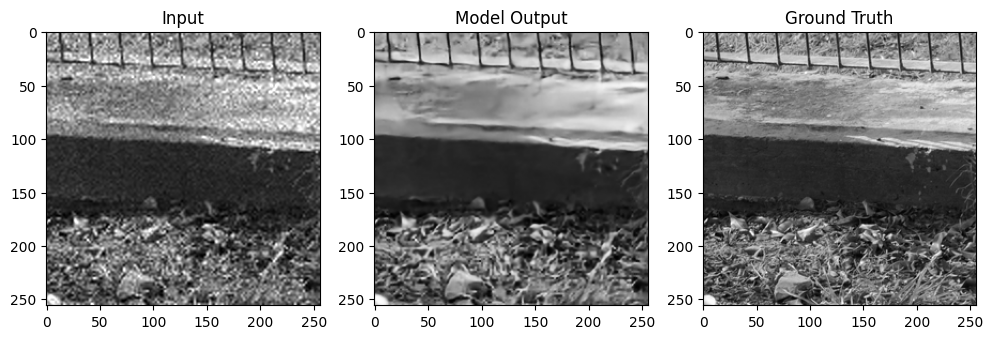

In [35]:
model.eval()
noisy, gt = next(iter(val_loader))
noisy, gt = noisy.to(device), gt.to(device)
with torch.no_grad():
    pred = model(noisy)

idx = 0
fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(noisy[idx,0].cpu(), cmap='gray'); ax[0].set_title('Input')
ax[1].imshow(pred[idx,0].cpu(), cmap='gray'); ax[1].set_title('Model Output')
ax[2].imshow(gt[idx,0].cpu(), cmap='gray'); ax[2].set_title('Ground Truth')
plt.show()

In [36]:
torch.save(model.state_dict(), '/content/drive/MyDrive/best_model_checkpoint.pth')

In [37]:
!ls -la /content/drive/MyDrive/best_model_checkpoint.pth

-rw------- 1 root root 1873621 Aug 13 18:28 /content/drive/MyDrive/best_model_checkpoint.pth


In [38]:
import lpips
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim_metric

loss_fn_lpips = lpips.LPIPS(net='alex').to(device)

model.eval()
psnr_scores, ssim_scores, lpips_scores = [], [], []

with torch.no_grad():
    for noisy, gt in val_loader:
        noisy, gt = noisy.to(device), gt.to(device)
        pred = model(noisy)

        for i in range(pred.shape[0]):
            p = pred[i,0].cpu().numpy()
            g = gt[i,0].cpu().numpy()
            psnr_scores.append(psnr(g, p, data_range=1.0))
            ssim_scores.append(ssim_metric(g, p, data_range=1.0))

        # LPIPS expects 3-channel, [-1,1] range
        pred_3ch = pred.repeat(1,3,1,1) * 2 - 1
        gt_3ch = gt.repeat(1,3,1,1) * 2 - 1
        lp = loss_fn_lpips(pred_3ch, gt_3ch)
        lpips_scores.extend(lp.squeeze().cpu().tolist())

print(f"Avg PSNR: {sum(psnr_scores)/len(psnr_scores):.3f}")
print(f"Avg SSIM: {sum(ssim_scores)/len(ssim_scores):.3f}")
print(f"Avg LPIPS: {sum(lpips_scores)/len(lpips_scores):.3f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 165MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Avg PSNR: 27.942
Avg SSIM: 0.773
Avg LPIPS: 0.296


In [39]:
import time

model.eval()
noisy, gt = next(iter(val_loader))
sample = noisy[0:1].to(device)

# warmup
with torch.no_grad():
    for _ in range(5):
        _ = model(sample)

torch.cuda.synchronize()
start = time.time()
with torch.no_grad():
    for _ in range(20):
        _ = model(sample)
torch.cuda.synchronize()
end = time.time()

avg_time = (end - start) / 20
print(f"Avg inference time per image: {avg_time*1000:.2f} ms")

# param count and model size
num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")
print(f"Model size (MB): {num_params * 4 / (1024**2):.2f}")

Avg inference time per image: 5.56 ms
Parameters: 465,953
Model size (MB): 1.78


In [40]:
for g in optimizer.param_groups:
    g['lr'] = 0.0003
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=15)

Epoch 1/15 — Train Loss: 0.0942, Val Loss: 0.0914, LR: 0.000300
  → New best model saved (val loss: 0.0914)
Epoch 2/15 — Train Loss: 0.0941, Val Loss: 0.0915, LR: 0.000300
Epoch 3/15 — Train Loss: 0.0941, Val Loss: 0.0914, LR: 0.000300
  → New best model saved (val loss: 0.0914)
Epoch 4/15 — Train Loss: 0.0941, Val Loss: 0.0913, LR: 0.000300
  → New best model saved (val loss: 0.0913)
Epoch 5/15 — Train Loss: 0.0940, Val Loss: 0.0914, LR: 0.000300
Epoch 6/15 — Train Loss: 0.0941, Val Loss: 0.0912, LR: 0.000300
  → New best model saved (val loss: 0.0912)
Epoch 7/15 — Train Loss: 0.0940, Val Loss: 0.0920, LR: 0.000300
Epoch 8/15 — Train Loss: 0.0939, Val Loss: 0.0911, LR: 0.000300
  → New best model saved (val loss: 0.0911)
Epoch 9/15 — Train Loss: 0.0939, Val Loss: 0.0920, LR: 0.000300
Epoch 10/15 — Train Loss: 0.0940, Val Loss: 0.0912, LR: 0.000300
Epoch 11/15 — Train Loss: 0.0939, Val Loss: 0.0916, LR: 0.000150
Epoch 12/15 — Train Loss: 0.0936, Val Loss: 0.0910, LR: 0.000150
  → New b

In [41]:
!ls -la /content/drive/MyDrive/ | grep -i -E "model|checkpoint|pth"

-rw------- 1 root root   1873621 Aug 13 18:28 best_model_checkpoint.pth


In [42]:
model = UNet().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_checkpoint.pth'))
model.eval()

UNet(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (up2): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
  (dec2): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2)

In [43]:
val_loss = 0
with torch.no_grad():
    for noisy, gt in val_loader:
        noisy, gt = noisy.to(device), gt.to(device)
        pred = model(noisy)
        val_loss += combined_loss(pred, gt).item()
val_loss /= len(val_loader)
print(f"Reloaded model val loss: {val_loss:.4f}")

Reloaded model val loss: 0.0914


In [44]:
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model = train_model(model, train_loader, val_loader, optimizer, device, epochs=25)

Epoch 1/25 — Train Loss: 0.1465, Val Loss: 0.1188, LR: 0.001000
  → New best model saved (val loss: 0.1188)
Epoch 2/25 — Train Loss: 0.1156, Val Loss: 0.1089, LR: 0.001000
  → New best model saved (val loss: 0.1089)
Epoch 3/25 — Train Loss: 0.1123, Val Loss: 0.1058, LR: 0.001000
  → New best model saved (val loss: 0.1058)
Epoch 4/25 — Train Loss: 0.1089, Val Loss: 0.1027, LR: 0.001000
  → New best model saved (val loss: 0.1027)
Epoch 5/25 — Train Loss: 0.1062, Val Loss: 0.1002, LR: 0.001000
  → New best model saved (val loss: 0.1002)
Epoch 6/25 — Train Loss: 0.1047, Val Loss: 0.1011, LR: 0.001000
Epoch 7/25 — Train Loss: 0.1036, Val Loss: 0.0993, LR: 0.001000
  → New best model saved (val loss: 0.0993)
Epoch 8/25 — Train Loss: 0.1025, Val Loss: 0.0984, LR: 0.001000
  → New best model saved (val loss: 0.0984)
Epoch 9/25 — Train Loss: 0.1022, Val Loss: 0.0977, LR: 0.001000
  → New best model saved (val loss: 0.0977)
Epoch 10/25 — Train Loss: 0.1009, Val Loss: 0.0975, LR: 0.001000
  → New

In [45]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_model_continued(model, train_loader, val_loader, optimizer, scheduler, device, epochs=15):
    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for noisy, gt in train_loader:
            noisy, gt = noisy.to(device), gt.to(device)
            optimizer.zero_grad()
            pred = model(noisy)
            loss = combined_loss(pred, gt)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for noisy, gt in val_loader:
                noisy, gt = noisy.to(device), gt.to(device)
                pred = model(noisy)
                loss = combined_loss(pred, gt)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"  → New best model saved (val loss: {val_loss:.4f})")

    model.load_state_dict(best_model_weights)
    return model

model = train_model_continued(model, train_loader, val_loader, optimizer, scheduler, device, epochs=15)

Epoch 1/15 — Train Loss: 0.0962, Val Loss: 0.0932, LR: 0.001000
  → New best model saved (val loss: 0.0932)
Epoch 2/15 — Train Loss: 0.0965, Val Loss: 0.0923, LR: 0.001000
  → New best model saved (val loss: 0.0923)
Epoch 3/15 — Train Loss: 0.0962, Val Loss: 0.0925, LR: 0.001000
Epoch 4/15 — Train Loss: 0.0956, Val Loss: 0.0923, LR: 0.001000
Epoch 5/15 — Train Loss: 0.0956, Val Loss: 0.0925, LR: 0.000500
Epoch 6/15 — Train Loss: 0.0946, Val Loss: 0.0919, LR: 0.000500
  → New best model saved (val loss: 0.0919)
Epoch 7/15 — Train Loss: 0.0946, Val Loss: 0.0917, LR: 0.000500
  → New best model saved (val loss: 0.0917)
Epoch 8/15 — Train Loss: 0.0945, Val Loss: 0.0914, LR: 0.000500
  → New best model saved (val loss: 0.0914)
Epoch 9/15 — Train Loss: 0.0945, Val Loss: 0.0914, LR: 0.000500
Epoch 10/15 — Train Loss: 0.0944, Val Loss: 0.0920, LR: 0.000500
Epoch 11/15 — Train Loss: 0.0945, Val Loss: 0.0921, LR: 0.000250
Epoch 12/15 — Train Loss: 0.0940, Val Loss: 0.0910, LR: 0.000250
  → New b

In [46]:
torch.save(model.state_dict(), '/content/drive/MyDrive/model_weights.pth')

In [47]:
import os
print(os.path.exists('/content/drive/MyDrive/model_weights.pth'))
print(os.path.getsize('/content/drive/MyDrive/model_weights.pth') / (1024*1024), "MB")

model_check = UNet().to(device)
model_check.load_state_dict(torch.load('/content/drive/MyDrive/model_weights.pth'))
model_check.eval()

val_loss = 0
with torch.no_grad():
    for noisy, gt in val_loader:
        noisy, gt = noisy.to(device), gt.to(device)
        pred = model_check(noisy)
        val_loss += combined_loss(pred, gt).item()
val_loss /= len(val_loader)
print(f"Confirmed val loss: {val_loss:.4f}")

True
1.7865800857543945 MB
Confirmed val loss: 0.0910


In [48]:
import lpips
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim_metric

loss_fn_lpips = lpips.LPIPS(net='alex').to(device)

model_check.eval()
psnr_scores, ssim_scores, lpips_scores = [], [], []

with torch.no_grad():
    for noisy, gt in val_loader:
        noisy, gt = noisy.to(device), gt.to(device)
        pred = model_check(noisy)

        for i in range(pred.shape[0]):
            p = pred[i,0].cpu().numpy()
            g = gt[i,0].cpu().numpy()
            psnr_scores.append(psnr(g, p, data_range=1.0))
            ssim_scores.append(ssim_metric(g, p, data_range=1.0))

        pred_3ch = pred.repeat(1,3,1,1) * 2 - 1
        gt_3ch = gt.repeat(1,3,1,1) * 2 - 1
        lp = loss_fn_lpips(pred_3ch, gt_3ch)
        lpips_scores.extend(lp.squeeze().cpu().tolist())

print(f"Avg PSNR: {sum(psnr_scores)/len(psnr_scores):.3f}")
print(f"Avg SSIM: {sum(ssim_scores)/len(ssim_scores):.3f}")
print(f"Avg LPIPS: {sum(lpips_scores)/len(lpips_scores):.3f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Avg PSNR: 27.936
Avg SSIM: 0.774
Avg LPIPS: 0.283


In [49]:
model_check = UNet().to(device)
model_check.load_state_dict(torch.load('/content/drive/MyDrive/model_weights.pth'))
model_check.eval()

val_loss = 0
with torch.no_grad():
    for noisy, gt in val_loader:
        noisy, gt = noisy.to(device), gt.to(device)
        pred = model_check(noisy)
        val_loss += combined_loss(pred, gt).item()
val_loss /= len(val_loader)
print(f"Currently saved model val loss: {val_loss:.4f}")

Currently saved model val loss: 0.0910
